# LIME Explainability Experiment: Attribution Strength & Faithfulness
This notebook evaluates and compares the interpretability of two fine-tuned models: **BERT** and **TPA-BERT** (Adversarial BERT) on the WELFake dataset.

### Key Metrics Defined:
1. **Average Attribution Strength**: The average absolute weight assigned by LIME to the top $K$ features (default $K=20$). This measures how "sharp" or "strong" the local explanation features are.
2. **Faithfulness**: The difference in model confidence after removing the most important words as determined by LIME:
   $$\text{Faithfulness} = P(\text{original}) - P(\text{after removing top-K words})$$
   We calculate this for different feature counts: $K \in \{5, 10, 20\}$.

### Execution Features:
* **Subset evaluation**: Evaluates on a stratified subset of the WELFake test split (default 10,000 samples).
* **Checkpointing**: Saves intermediate results every 100 samples to Google Drive so that long runs can be resumed if Google Colab disconnects.
* **Quick-verify mode**: Allows setting `LIMIT_SAMPLES` to a small number (e.g. 10) to verify the entire pipeline runs without errors in minutes.

## Section 1: Environment Setup

In [13]:
!pip install lime -q

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import json
import os
import re
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertModel, BertForSequenceClassification
from lime.lime_text import LimeTextExplainer

try:
    import torch_xla as torch_xla_pkg
    import torch_xla.core.xla_model as xm
    if not hasattr(torch, "xla"):
        torch.xla = torch_xla_pkg
    _TORCH_XLA_AVAILABLE = True
except Exception:
    xm = None
    _TORCH_XLA_AVAILABLE = False

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print("Colab drive module not available or not running in Colab. Manual paths will be used.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Section 2: Experiment Configuration

In [ ]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# Dataset and model paths
DATASET_PATH = "/content/drive/MyDrive/datasets/WELFake_processed.csv"
BERT_PATH = "/content/drive/MyDrive/bert_models/WELFake"
TPA_BERT_DIR = "/content/drive/MyDrive/models/AdversarialBERT_WELFake"
TPA_BERT_WEIGHTS = "adversarial_bert.pt"

# Experiment settings
NUM_SAMPLES = 10000       # Target sample size for evaluation
NUM_PERTURBATIONS = 1000  # Number of LIME perturbations per sample
NUM_FEATURES = 20         # Number of LIME features to explain

# K values to calculate Faithfulness for
K_VALUES = [5, 10, 20]

# Checkpointing paths
CHECKPOINT_PATH = "/content/drive/MyDrive/models/lime_eval_checkpoint.json"
FINAL_RESULTS_PATH = "/content/drive/MyDrive/models/lime_eval_results_final.json"

# Quick check configuration (Set to an integer like 10 to do a dry run, set to None for full run)
LIMIT_SAMPLES = None

# Set whether to sample from the entire dataset or from the held-out test split
EVAL_ON_FULL_DATASET = False  # False = held-out test split only (max 9,551), True = full dataset (10,000)

CLASS_NAMES = ['Fake', 'Real']


## Section 3: Model Architecture Definitions

In [15]:
class AdversarialBERT(nn.Module):
    """TPA-BERT model architecture."""
    def __init__(self, num_labels=2, dropout=0.1):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(768, num_labels)

    def forward(self, input_ids, attention_mask, token_type_ids=None, **kwargs):
        if token_type_ids is not None:
            out = self.bert(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        else:
            out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb = out.last_hidden_state[:, 0, :]
        logits = self.classifier(self.dropout(cls_emb))
        return logits, cls_emb


## Section 4: Word Removal Helper Function

In [16]:
def remove_top_k_words(text, top_k_words):
    """Recreates text with the top-K words removed.
    
    Splits text on non-word boundaries (matching LIME's internal splitter)
    and removes all occurrences of the specified words in a case-insensitive manner.
    """
    tokens = re.split(r'(\W+)', text)
    words_to_remove = set(w.lower() for w in top_k_words)
    new_tokens = []
    for token in tokens:
        if token.lower() in words_to_remove:
            new_tokens.append("")
        else:
            new_tokens.append(token)
    return "".join(new_tokens)

# Sanity Check for word removal
sample_text = "Colombian police seize 7 tons of cocaine at banana farm. Reuters news."
print("Original:", sample_text)
print("Removed ['police', 'cocaine', 'reuters']:", remove_top_k_words(sample_text, ['police', 'cocaine', 'reuters']))


Original: Colombian police seize 7 tons of cocaine at banana farm. Reuters news.
Removed ['police', 'cocaine', 'reuters']: Colombian  seize 7 tons of  at banana farm.  news.


## Section 5: Data Loading & Test Stratification

In [17]:
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"Dataset path not found: {DATASET_PATH}. Please check your Drive mount and paths.")

df = pd.read_csv(DATASET_PATH).dropna()
print(f"✓ Original dataset loaded: {len(df)} rows")
print(f"Label distribution:\n{df['label'].value_counts()}")

# Recreate the train/test split from training (same random_state=42 and test_size=0.15)
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['combined_text'].tolist(),
    df['label'].tolist(),
    test_size=0.15,
    random_state=42,
    stratify=df['label']
)
print(f"\n✓ Held-out test split size: {len(test_texts)} samples")

# Choose evaluation dataset based on config
if EVAL_ON_FULL_DATASET:
    print(f"Sampling {NUM_SAMPLES} samples from the entire dataset...")
    eval_df = df.sample(n=NUM_SAMPLES, random_state=42, stratify=df['label']).reset_index(drop=True)
else:
    print(f"Using the complete held-out test split ({len(test_texts)} samples) directly...")
    eval_df = pd.DataFrame({'text': test_texts, 'label': test_labels}).reset_index(drop=True)

print(f"\n✓ Evaluation set created: {len(eval_df)} samples")
print(eval_df['label'].value_counts())


✓ Original dataset loaded: 63670 rows
Label distribution:
label
0    34790
1    28880
Name: count, dtype: int64

✓ Held-out test split size: 9551 samples
Using the complete held-out test split (9551 samples) directly...

✓ Evaluation set created: 9551 samples
label
0    5219
1    4332
Name: count, dtype: int64


## Section 6: Load Models & Set Up Predictors

In [18]:
def load_device():
    if _TORCH_XLA_AVAILABLE and xm is not None:
        try:
            device = xm.xla_device()
            print(f"✓ Using TPU: {device}\n")
            return device
        except Exception:
            pass
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"✓ Using CUDA: {torch.cuda.get_device_name(0)}\n")
    else:
        device = torch.device("cpu")
        print("⚠ Using CPU\n")
    return device

device = load_device()

# Load Tokenizer (common for both since both are bert-base-uncased backbones)
tokenizer = BertTokenizer.from_pretrained(BERT_PATH)

# Load BERT
print("Loading standard BERT model...")
model_bert = BertForSequenceClassification.from_pretrained(BERT_PATH)
model_bert.to(device)
model_bert.eval()
print("✓ Standard BERT loaded successfully")

# Load TPA-BERT
print("Loading Adversarial TPA-BERT model...")
model_tpa = AdversarialBERT()
tpa_weights_path = os.path.join(TPA_BERT_DIR, TPA_BERT_WEIGHTS)
state_dict = torch.load(tpa_weights_path, map_location="cpu")
model_tpa.load_state_dict(state_dict)
model_tpa.to(device)
model_tpa.eval()
print("✓ TPA-BERT loaded successfully")

# Define predictors with static padding ('max_length') to prevent dynamic compile loops on TPU
def predict_proba_bert(texts):
    all_probs = []
    batch_size = 64
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        encodings = tokenizer(
            batch,
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='pt'
        )
        encodings = {k: v.to(device) for k, v in encodings.items()}
        with torch.no_grad():
            outputs = model_bert(**encodings)
            probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
            all_probs.append(probs.cpu().numpy())
    return np.concatenate(all_probs, axis=0)

def predict_proba_tpa(texts):
    all_probs = []
    batch_size = 64
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        encodings = tokenizer(
            batch,
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='pt'
        )
        encodings = {k: v.to(device) for k, v in encodings.items()}
        with torch.no_grad():
            logits, _ = model_tpa(**encodings)
            probs = torch.nn.functional.softmax(logits, dim=-1)
            all_probs.append(probs.cpu().numpy())
    return np.concatenate(all_probs, axis=0)

# Sanity check
test_text = [eval_df.iloc[0]['text']]
print("\nPredictor test:")
print("BERT predictions:   ", predict_proba_bert(test_text)[0])
print("TPA-BERT predictions:", predict_proba_tpa(test_text)[0])


✓ Using TPU: xla:0

Loading standard BERT model...


/tmp/ipykernel_872/800338086.py:4: DeprecationWarning: Use torch_xla.device instead
  device = xm.xla_device()


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✓ Standard BERT loaded successfully
Loading Adversarial TPA-BERT model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ TPA-BERT loaded successfully

Predictor test:
BERT predictions:    [9.9998009e-01 1.9870064e-05]
TPA-BERT predictions: [0.99849033 0.00150964]


## Section 7: Main Experiment Loop (With Checkpointing)

In [19]:
# Set up LIME Explainer
explainer = LimeTextExplainer(
    class_names=CLASS_NAMES,
    random_state=42
)

# Results structure
results = {
    "bert": [],
    "tpa_bert": []
}

start_index = 0
checkpoint_dir = os.path.dirname(CHECKPOINT_PATH)
if checkpoint_dir:
    os.makedirs(checkpoint_dir, exist_ok=True)

# Resume checkpoint if exists
if os.path.exists(CHECKPOINT_PATH):
    try:
        with open(CHECKPOINT_PATH, 'r') as f:
            checkpoint = json.load(f)
        results = checkpoint["results"]
        start_index = checkpoint["last_index"] + 1
        print(f"✓ Resuming from checkpoint at index {start_index}...")
    except Exception as e:
        print(f"⚠ Error loading checkpoint: {e}. Starting from scratch.")

# Apply quick run limit if set
samples_to_evaluate = eval_df.iloc[start_index:]
if LIMIT_SAMPLES is not None:
    # Adjust limit relative to start index
    remaining_limit = max(0, LIMIT_SAMPLES - start_index)
    samples_to_evaluate = eval_df.iloc[start_index:start_index + remaining_limit]
    print(f"⚠ QUICK RUN ENABLED (LIMIT_SAMPLES={LIMIT_SAMPLES}). Running on {len(samples_to_evaluate)} samples.")
else:
    print(f"Running full experiment on {len(samples_to_evaluate)} samples.")

t0 = time.time()
for current_idx, (idx, row) in enumerate(samples_to_evaluate.iterrows()):
    global_idx = start_index + current_idx
    text = row['text']
    true_label = int(row['label'])
    
    # ─── BERT Explanation ───
    probs_bert = predict_proba_bert([text])[0]
    pred_bert = int(np.argmax(probs_bert))
    p_orig_bert = float(probs_bert[pred_bert])
    
    exp_bert = explainer.explain_instance(
        text,
        predict_proba_bert,
        num_features=NUM_FEATURES,
        num_samples=NUM_PERTURBATIONS,
        labels=(pred_bert,)
    )
    
    weights_bert = exp_bert.as_list(label=pred_bert)
    sorted_features_bert = sorted(weights_bert, key=lambda x: abs(x[1]), reverse=True)
    attr_strength_bert = float(np.mean([abs(w[1]) for w in sorted_features_bert]))
    
    faithfulness_bert = {}
    for k in K_VALUES:
        top_k_words = [w[0] for w in sorted_features_bert[:k]]
        modified_text = remove_top_k_words(text, top_k_words)
        probs_mod = predict_proba_bert([modified_text])[0]
        p_mod = float(probs_mod[pred_bert])
        faithfulness_bert[str(k)] = p_orig_bert - p_mod
        
    results["bert"].append({
        "index": int(global_idx),
        "true_label": true_label,
        "predicted_label": pred_bert,
        "p_original": p_orig_bert,
        "attribution_strength": attr_strength_bert,
        "faithfulness": faithfulness_bert
    })
    
    # ─── TPA-BERT Explanation ───
    probs_tpa = predict_proba_tpa([text])[0]
    pred_tpa = int(np.argmax(probs_tpa))
    p_orig_tpa = float(probs_tpa[pred_tpa])
    
    exp_tpa = explainer.explain_instance(
        text,
        predict_proba_tpa,
        num_features=NUM_FEATURES,
        num_samples=NUM_PERTURBATIONS,
        labels=(pred_tpa,)
    )
    
    weights_tpa = exp_tpa.as_list(label=pred_tpa)
    sorted_features_tpa = sorted(weights_tpa, key=lambda x: abs(x[1]), reverse=True)
    attr_strength_tpa = float(np.mean([abs(w[1]) for w in sorted_features_tpa]))
    
    faithfulness_tpa = {}
    for k in K_VALUES:
        top_k_words = [w[0] for w in sorted_features_tpa[:k]]
        modified_text = remove_top_k_words(text, top_k_words)
        probs_mod = predict_proba_tpa([modified_text])[0]
        p_mod = float(probs_mod[pred_tpa])
        faithfulness_tpa[str(k)] = p_orig_tpa - p_mod
        
    results["tpa_bert"].append({
        "index": int(global_idx),
        "true_label": true_label,
        "predicted_label": pred_tpa,
        "p_original": p_orig_tpa,
        "attribution_strength": attr_strength_tpa,
        "faithfulness": faithfulness_tpa
    })
    
    # Checkpointing every 100 samples
    if (global_idx + 1) % 100 == 0 or global_idx == len(eval_df) - 1 or (LIMIT_SAMPLES is not None and (current_idx + 1) == len(samples_to_evaluate)):
        checkpoint_data = {
            "last_index": int(global_idx),
            "results": results
        }
        with open(CHECKPOINT_PATH, 'w') as f:
            json.dump(checkpoint_data, f, indent=2)
            
        elapsed = time.time() - t0
        per_sample = elapsed / (current_idx + 1)
        remaining = len(samples_to_evaluate) - (current_idx + 1)
        eta = per_sample * remaining
        print(f"Sample {global_idx+1}/{len(eval_df)} saved to checkpoint. "
              f"Elapsed: {elapsed/60:.1f}m. Per-sample: {per_sample:.2f}s. ETA: {eta/60:.1f}m")

# Final Save
final_dir = os.path.dirname(FINAL_RESULTS_PATH)
if final_dir:
    os.makedirs(final_dir, exist_ok=True)
with open(FINAL_RESULTS_PATH, 'w') as f:
    json.dump(results, f, indent=2)
print("✓ Experiment complete! Final results saved to:", FINAL_RESULTS_PATH)


⚠ QUICK RUN ENABLED (LIMIT_SAMPLES=10). Running on 10 samples.
Sample 10/9551 saved to checkpoint. Elapsed: 0.7m. Per-sample: 4.38s. ETA: 0.0m
✓ Experiment complete! Final results saved to: /content/drive/MyDrive/models/lime_eval_results_final.json


## Section 8: Analysis, Metrics Aggregation & Plots

Analyzing 10 completed explanations...

                        METRIC COMPARISON                        
Metric                              | BERT         | TPA-BERT (Adv)
-----------------------------------------------------------------
Avg Attribution Strength (Top 20)   | 0.032663     | 0.016128
Avg Faithfulness (K=5)              | 0.313290     | -0.005964
Avg Faithfulness (K=10)             | 0.302973     | 0.026970
Avg Faithfulness (K=20)             | 0.392427     | 0.005594

✓ Visualization saved to: /content/lime_evaluation_plots.png


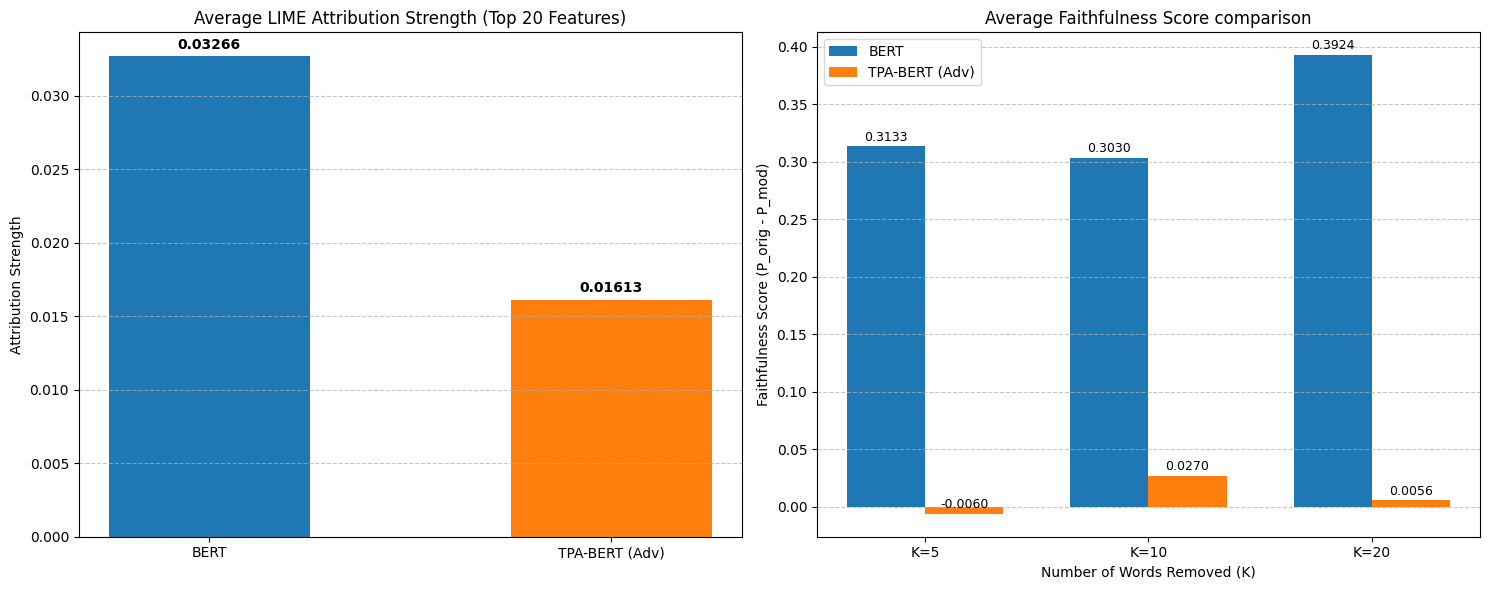

In [20]:
# Load final results if we ran from scratch or check if file exists
if os.path.exists(FINAL_RESULTS_PATH):
    with open(FINAL_RESULTS_PATH, 'r') as f:
        results = json.load(f)
elif os.path.exists(CHECKPOINT_PATH):
    with open(CHECKPOINT_PATH, 'r') as f:
        checkpoint = json.load(f)
        results = checkpoint["results"]
        print("⚠ FINAL_RESULTS_PATH not found, using intermediate results from checkpoint.")
else:
    raise FileNotFoundError("No results or checkpoint found to analyze.")

df_bert = pd.DataFrame(results["bert"])
df_tpa = pd.DataFrame(results["tpa_bert"])

print(f"Analyzing {len(df_bert)} completed explanations...")

# Calculate Means
mean_strength_bert = df_bert['attribution_strength'].mean()
mean_strength_tpa = df_tpa['attribution_strength'].mean()

mean_faith_bert = {k: np.mean([f[str(k)] for f in df_bert['faithfulness']]) for k in K_VALUES}
mean_faith_tpa = {k: np.mean([f[str(k)] for f in df_tpa['faithfulness']]) for k in K_VALUES}

print("\n" + "="*65)
print(f"{'METRIC COMPARISON':^65}")
print("="*65)
print(f"{'Metric':<35} | {'BERT':<12} | {'TPA-BERT (Adv)':<12}")
print("-"*65)
print(f"{'Avg Attribution Strength (Top 20)':<35} | {mean_strength_bert:.6f}     | {mean_strength_tpa:.6f}")
for k in K_VALUES:
    print(f"{f'Avg Faithfulness (K={k})':<35} | {mean_faith_bert[k]:.6f}     | {mean_faith_tpa[k]:.6f}")
print("="*65)

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Attribution Strength
bars = axes[0].bar(['BERT', 'TPA-BERT (Adv)'], [mean_strength_bert, mean_strength_tpa], color=['#1f77b4', '#ff7f0e'], width=0.5)
axes[0].set_ylabel('Attribution Strength')
axes[0].set_title('Average LIME Attribution Strength (Top 20 Features)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars:
    height = bar.get_height()
    axes[0].annotate(f'{height:.5f}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),  # 3 points vertical offset
                     textcoords="offset points",
                     ha='center', va='bottom', fontweight='bold')

# Plot 2: Faithfulness comparison
x = np.arange(len(K_VALUES))
width = 0.35
axes[1].bar(x - width/2, [mean_faith_bert[k] for k in K_VALUES], width, label='BERT', color='#1f77b4')
axes[1].bar(x + width/2, [mean_faith_tpa[k] for k in K_VALUES], width, label='TPA-BERT (Adv)', color='#ff7f0e')
axes[1].set_ylabel('Faithfulness Score (P_orig - P_mod)')
axes[1].set_xlabel('Number of Words Removed (K)')
axes[1].set_title('Average Faithfulness Score comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'K={k}' for k in K_VALUES])
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Annotate Faithfulness bars
for i, k in enumerate(K_VALUES):
    axes[1].annotate(f'{mean_faith_bert[k]:.4f}', xy=(i - width/2, mean_faith_bert[k]), xytext=(0, 2), textcoords="offset points", ha='center', va='bottom', fontsize=9)
    axes[1].annotate(f'{mean_faith_tpa[k]:.4f}', xy=(i + width/2, mean_faith_tpa[k]), xytext=(0, 2), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plot_output_path = "/content/lime_evaluation_plots.png"
plt.savefig(plot_output_path, dpi=300)
print(f"\n✓ Visualization saved to: {plot_output_path}")
plt.show()
